# Appendix D: Stable Curves of Genus Zero

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix D, printed pp. 619-652; PDF pp. 634-667. Sections D.1-D.7 are used for coverage planning only.

**Appendix question.** How do marked spheres compactify when points collide, and why do trees, cross-ratios, and boundary divisors give a usable coordinate system for genus-zero stable curves? This appendix supplies the combinatorial domain theory behind stable maps and Gromov-Witten splitting. The notebook treats it as a visual atlas: Mobius-normalized marked points, cross-ratio degeneration, stable dual trees, Grothendieck-Knudsen boundary strata, Gromov-neighborhood tests, and Keel/psi-class bookkeeping.

The guiding idea is that a stable curve is not a singular accident. It is a controlled boundary point in a compact moduli space. The computations below check the invariants that make that boundary usable: cross-ratio invariance, stability valence, dimension `n-3`, boundary-splitting compatibility, and simple psi-class recursion cases.


## Source Coverage

Section D.1 establishes Mobius transformations and cross-ratios as coordinates for four marked points. Section D.2 introduces trees, labels, and splittings; these encode which marks live on which component after degeneration. Sections D.3 and D.4 define stable curves and construct the Grothendieck-Knudsen compactification. Section D.5 gives the Gromov topology for stable domains. Section D.6 records cohomology facts, including Keel relations and psi-class intersection recursion. Section D.7 works through examples that make the compactification concrete.

The notebook maps those sections onto generated artifacts: a cross-ratio degeneration path, a Mobius-invariance JSON check, a stable dual-tree figure, a boundary divisor and splitting graph, a Gromov-topology neighborhood ledger, and psi-class recursion tables. No source text or figures are copied.


In [1]:
from pathlib import Path
import itertools
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp


def find_book_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "J-Holomorphic-Curves-and-Symplectic-Topology" / "AGENTS.md").exists():
            return candidate / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and candidate.name == "J-Holomorphic-Curves-and-Symplectic-Topology":
            return candidate
    raise RuntimeError("Could not locate the JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "appendix-d"
ART_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ART_ROOT / "figures"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Appendix D",
    "source_span_used": "printed pp. 619-652; PDF pp. 634-667",
    "sections": [
        {"section": "D.1", "focus": "Mobius transformations and cross-ratios", "artifact": "cross-ratio-boundary-degeneration.png"},
        {"section": "D.2", "focus": "trees, labels, and splittings", "artifact": "stable-tree-splitting-map.png"},
        {"section": "D.3", "focus": "stable curves and stability conditions", "artifact": "stable-tree-splitting-map.png"},
        {"section": "D.4", "focus": "Grothendieck-Knudsen compactification", "artifact": "gk-boundary-divisor-atlas.png"},
        {"section": "D.5", "focus": "Gromov topology for stable curves", "artifact": "gromov-topology-neighborhood-ledger.csv"},
        {"section": "D.6", "focus": "Keel cohomology and psi-class recursion", "artifact": "psi-class-recursion-ledger.csv"},
        {"section": "D.7", "focus": "examples of low-marked moduli spaces", "artifact": "marked-sphere-dimension-lab.csv"},
    ],
    "copyright_boundary": "Original prose and generated combinatorial diagrams only; no copied source material.",
}
library_routing = {
    "sympy": "cross-ratio and Mobius invariance are exact rational identities",
    "matplotlib": "marked-point degeneration and boundary atlases are two-dimensional diagrams",
    "networkx": "dual trees and splitting strata are graph objects",
    "pandas": "stability, topology, and psi-recursion cases are best kept in ledgers",
}
visual_storyboard = [
    {"visual": "cross-ratio-boundary-degeneration.png", "concept": "four marked points approach a boundary stratum", "inspection_target": "the cross-ratio tends toward 0, 1, or infinity depending on collision", "invariant": "Mobius transforms preserve the cross-ratio"},
    {"visual": "stable-tree-splitting-map.png", "concept": "dual tree for a nodal stable sphere", "inspection_target": "every component has at least three special points", "invariant": "stability valence check passes on all vertices"},
    {"visual": "gk-boundary-divisor-atlas.png", "concept": "Grothendieck-Knudsen boundary divisors", "inspection_target": "splittings I|J identify codimension-one boundary strata", "invariant": "each listed split has both sides of size at least two"},
    {"visual": "moduli-proof-dependency-map.png", "concept": "proof flow from cross-ratios to compactification and cohomology", "inspection_target": "coordinates, trees, topology, and relations feed GW domains", "invariant": "all seven source sections appear"},
    {"visual": "marked-sphere-dimension-lab.csv", "concept": "dimension and psi recursion", "inspection_target": "M_0,n has dimension n-3", "invariant": "psi powers sum to n-3 for nonzero genus-zero intersections"},
]
save_json(source_coverage, UNIT, "checks", "source-coverage.json")
save_json(library_routing, UNIT, "checks", "library-routing.json")
save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/appendix-d/checks/visual-storyboard.json')

## Library Routing

Appendix D is naturally combinatorial. SymPy checks cross-ratio invariance exactly, avoiding numerical ambiguity near degenerations. NetworkX represents stable trees and proof dependencies because nodal curves are tree-shaped domains with labelled leaves. Matplotlib gives durable pictures of marked points and boundary atlases. Pandas records stability and cohomology ledgers so the reader can inspect which conditions are being tested.

## Visualization Storyboard

The notebook begins with four marked points on a sphere after Mobius normalization and tracks a cross-ratio moving toward the boundary. It then turns a nodal sphere into a labelled tree and checks stability at each component. The Grothendieck-Knudsen compactification is shown as a boundary-divisor atlas of stable splittings. A proof map connects cross-ratio coordinates, trees, stable curves, Gromov topology, and cohomology. The applied lab computes `dim M_0,n = n-3` and checks the genus-zero psi rule that nonzero intersections require the total psi power to equal that dimension.


## 1. Cross-Ratio Degeneration and Mobius Invariance

Four labelled points on a sphere have one essential parameter after Mobius transformations. With three points normalized to `0`, `1`, and `infinity`, the fourth point is the cross-ratio coordinate. Boundary strata appear when that coordinate approaches `0`, `1`, or `infinity`, meaning marks collide and a new component bubbles off. The plot below shows the path toward zero; the exact check verifies that a sample Mobius transformation preserves the cross-ratio.


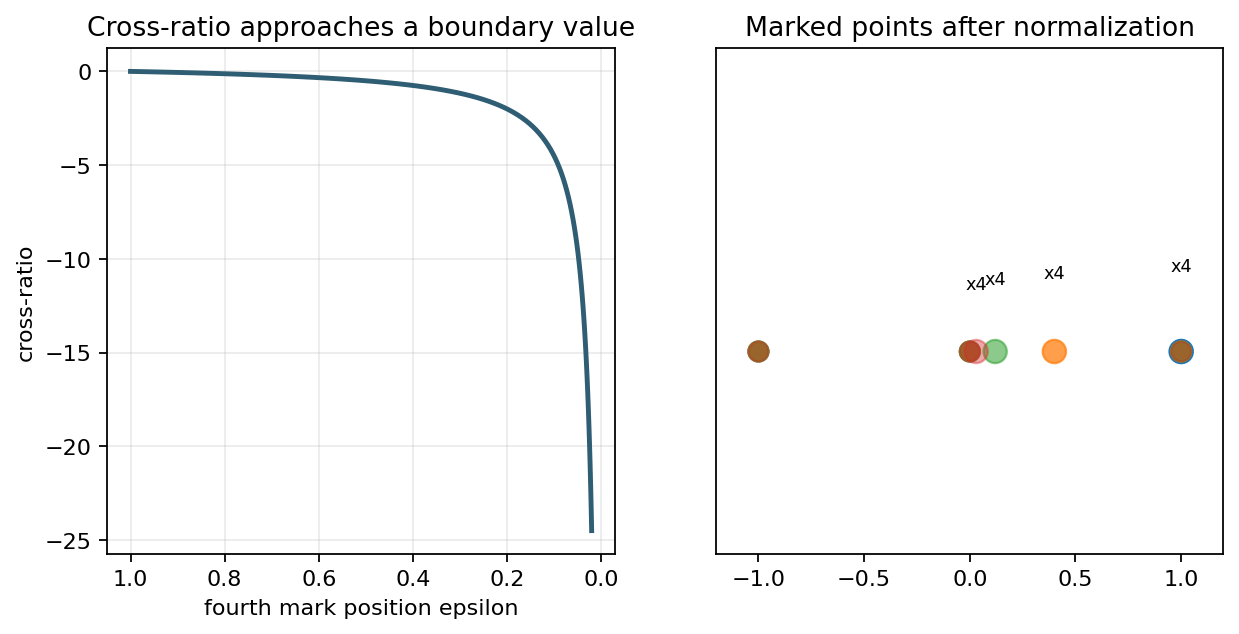

In [3]:
def cross_ratio(a, b, c, d):
    return ((a - c) * (b - d)) / ((a - d) * (b - c))

eps = np.geomspace(1.0, 0.02, 80)
points = [(0, 1, -1, e) for e in eps]
cr_values = np.array([cross_ratio(*p) for p in points], dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.1))
axes[0].plot(eps, cr_values, color="#2f5d73", lw=2.2)
axes[0].invert_xaxis()
axes[0].set_xlabel("fourth mark position epsilon")
axes[0].set_ylabel("cross-ratio")
axes[0].set_title("Cross-ratio approaches a boundary value")
axes[0].grid(alpha=0.25)
for e, alpha in [(1.0, 1.0), (0.4, 0.75), (0.12, 0.55), (0.03, 0.4)]:
    axes[1].scatter([0, 1, -1, e], [0, 0, 0, 0], s=[80,80,80,110], alpha=alpha)
    axes[1].text(e, 0.05 + 0.03*alpha, "x4", ha="center", fontsize=8)
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-0.2, 0.3)
axes[1].set_yticks([])
axes[1].set_title("Marked points after normalization")
fig_path = save_matplotlib(fig, UNIT, "figures", "cross-ratio-boundary-degeneration.png")
plt.close(fig)

z1, z2, z3, z4 = sp.Rational(0), sp.Rational(1), sp.Rational(-1), sp.Rational(2)
def mobius(z):
    return (2*z + 3)/(z + 5)
cr_before = sp.simplify(cross_ratio(z1, z2, z3, z4))
cr_after = sp.simplify(cross_ratio(mobius(z1), mobius(z2), mobius(z3), mobius(z4)))
cr_checks = {"cross_ratio_before": str(cr_before), "cross_ratio_after_mobius": str(cr_after), "invariant": bool(sp.simplify(cr_before - cr_after) == 0), "degeneration_final_value": float(cr_values[-1]), "passed": bool(sp.simplify(cr_before - cr_after) == 0 and cr_values[-1] < cr_values[0])}
save_json(cr_checks, UNIT, "checks", "cross-ratio-invariance-checks.json")
display_artifact(fig_path, width=880)


## 2. Stable Trees, Labels, and Splittings

A genus-zero stable curve is encoded by a tree. Vertices are sphere components, leaves are marked points, and internal edges are nodes. Stability says that every component must have at least three special points, counting marks and nodes. This condition removes continuous automorphisms. The graph below displays a five-marked stable curve with one node; the ledger checks the stability valence at every component and records the corresponding splitting of labels.


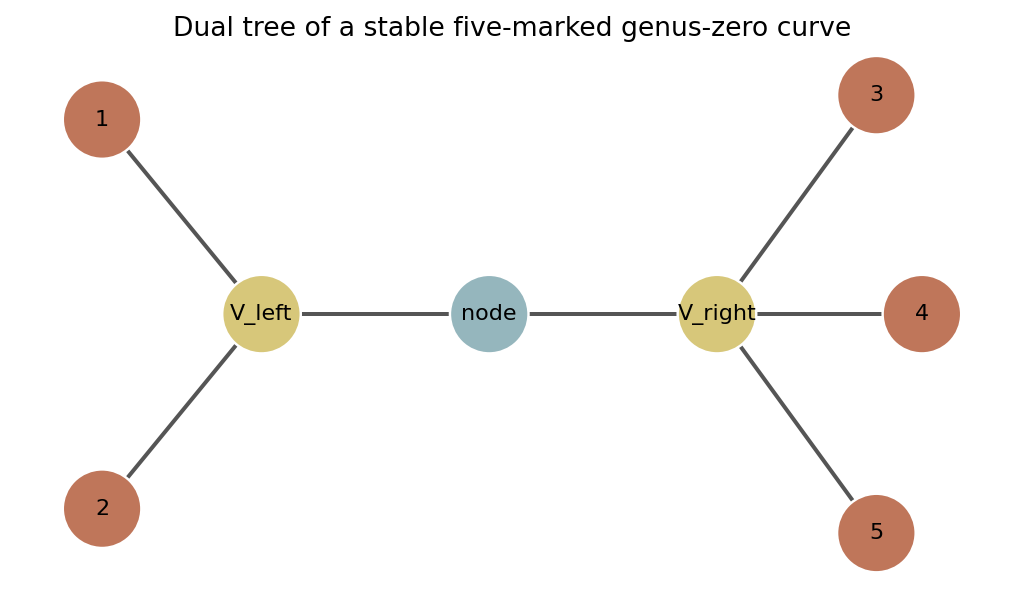

In [4]:
T = nx.Graph()
T.add_edges_from([("V_left", "node"), ("node", "V_right"), ("V_left", "1"), ("V_left", "2"), ("V_right", "3"), ("V_right", "4"), ("V_right", "5")])
pos = {"V_left": (-1,0), "node": (0,0), "V_right": (1,0), "1": (-1.7,0.8), "2": (-1.7,-0.8), "3": (1.7,0.9), "4": (1.9,0), "5": (1.7,-0.9)}
colors = ["#d7c77a" if n.startswith("V") else "#95b6bd" if n == "node" else "#bf765a" for n in T.nodes]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
nx.draw_networkx_nodes(T, pos, node_color=colors, node_size=1250, edgecolors="white", linewidths=1.1, ax=ax)
nx.draw_networkx_edges(T, pos, width=1.8, edge_color="#555", ax=ax)
nx.draw_networkx_labels(T, pos, font_size=10, ax=ax)
ax.set_title("Dual tree of a stable five-marked genus-zero curve")
ax.axis("off")
fig_path = save_matplotlib(fig, UNIT, "figures", "stable-tree-splitting-map.png")
plt.close(fig)
stability = pd.DataFrame([
    {"component": "V_left", "marks": "1,2", "nodes": 1, "special_points": 3, "stable": True, "split_side": "{1,2}"},
    {"component": "V_right", "marks": "3,4,5", "nodes": 1, "special_points": 4, "stable": True, "split_side": "{3,4,5}"},
])
stability.to_csv(TABLE_DIR / "stable-tree-stability-ledger.csv", index=False)
stability_checks = {"components": int(len(stability)), "all_components_stable": bool(stability["stable"].all()), "minimum_special_points": int(stability["special_points"].min()), "splitting": "{1,2}|{3,4,5}", "passed": bool(stability["stable"].all() and stability["special_points"].min() >= 3)}
save_json(stability_checks, UNIT, "checks", "stable-tree-stability-checks.json")
display_artifact(fig_path, width=800)


## 3. Grothendieck-Knudsen Boundary Atlas and Proof Map

The compactification `Mbar_0,n` adds strata indexed by stable label splittings. A codimension-one boundary divisor corresponds to a partition `I|J` with at least two labels on each side. The atlas below lists representative splits for five marks and the proof map records the appendix flow: cross-ratios provide coordinates, trees encode degenerations, stability builds the compactification, Gromov topology controls convergence, and Keel relations describe cohomology.


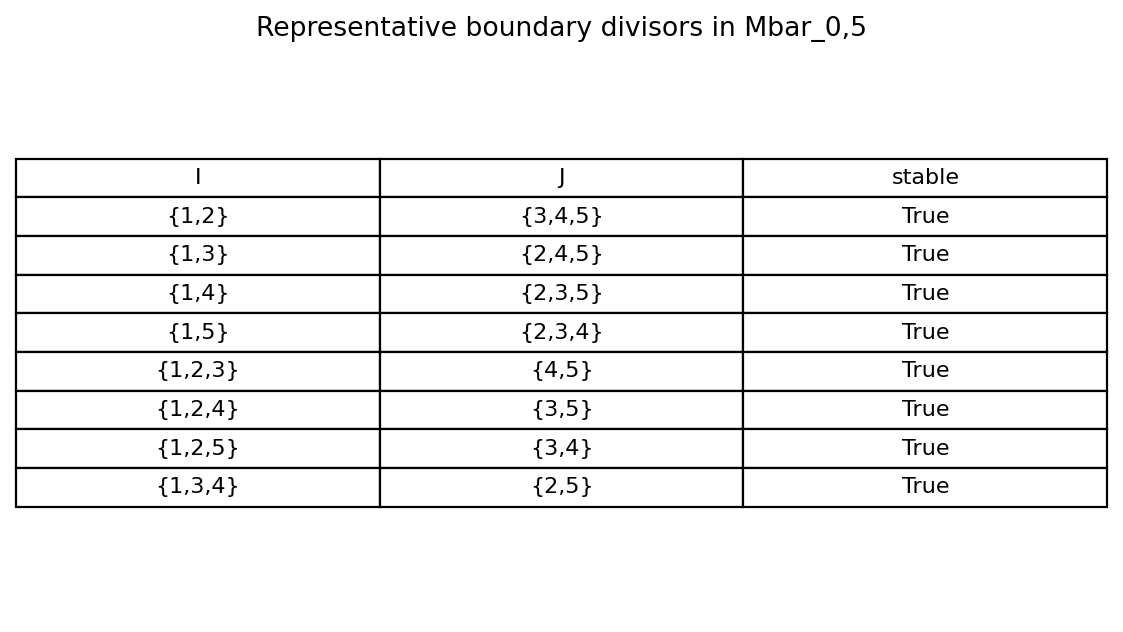

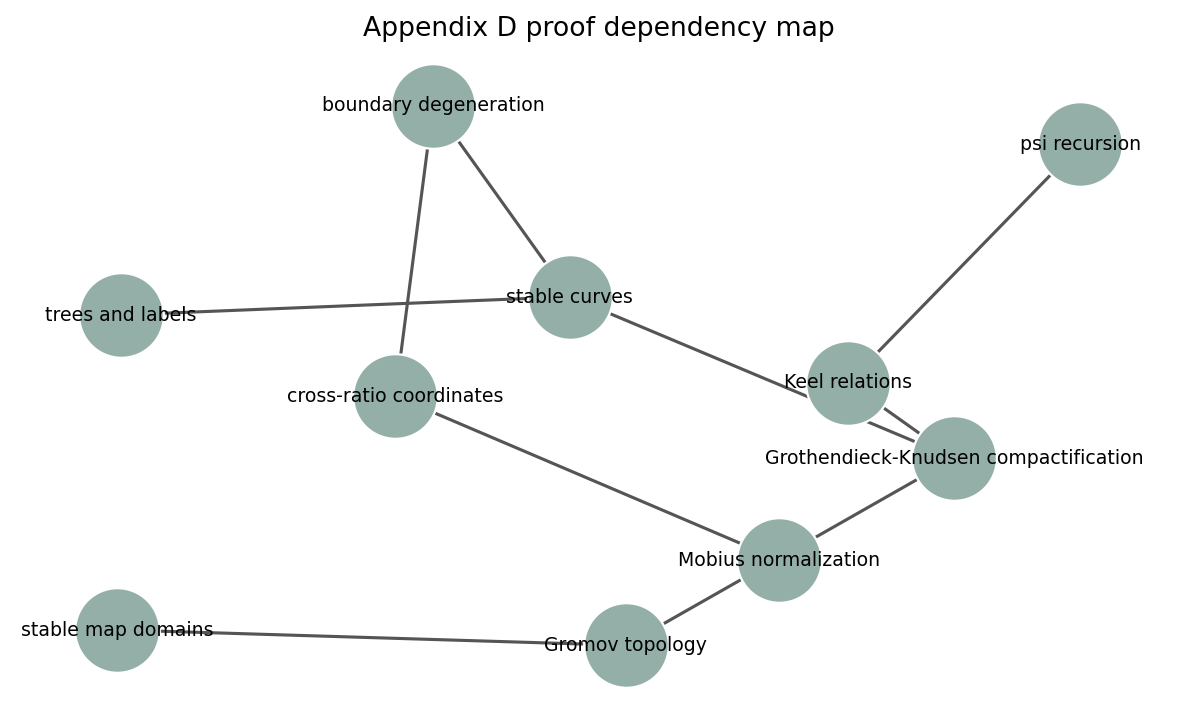

In [5]:
labels = {1,2,3,4,5}
splits = []
for r in range(2, len(labels)-1):
    for I in itertools.combinations(sorted(labels), r):
        I = set(I)
        J = labels - I
        if min(I) == min(labels):
            splits.append({"I": "{" + ",".join(map(str, sorted(I))) + "}", "J": "{" + ",".join(map(str, sorted(J))) + "}", "size_I": len(I), "size_J": len(J), "stable_divisor": len(I) >= 2 and len(J) >= 2})
splits_df = pd.DataFrame(splits)
splits_df.to_csv(TABLE_DIR / "gk-boundary-splittings.csv", index=False)
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.axis("off")
cell_text = splits_df.head(8)[["I", "J", "stable_divisor"]].values
rendered = ax.table(cellText=cell_text, colLabels=["I", "J", "stable"], loc="center", cellLoc="center")
rendered.auto_set_font_size(False)
rendered.set_fontsize(10)
rendered.scale(1.1, 1.45)
ax.set_title("Representative boundary divisors in Mbar_0,5")
fig_path = save_matplotlib(fig, UNIT, "figures", "gk-boundary-divisor-atlas.png")
plt.close(fig)

G = nx.DiGraph()
G.add_edges_from([
    ("Mobius normalization", "cross-ratio coordinates"),
    ("cross-ratio coordinates", "boundary degeneration"),
    ("trees and labels", "stable curves"),
    ("boundary degeneration", "stable curves"),
    ("stable curves", "Grothendieck-Knudsen compactification"),
    ("Grothendieck-Knudsen compactification", "Gromov topology"),
    ("Grothendieck-Knudsen compactification", "Keel relations"),
    ("Keel relations", "psi recursion"),
    ("Gromov topology", "stable map domains"),
])
pos = nx.spring_layout(G, seed=45, k=1.0)
fig, ax = plt.subplots(figsize=(9.4, 5.3))
nx.draw_networkx_nodes(G, pos, node_color="#93afa7", node_size=1450, edgecolors="white", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=14, width=1.4, edge_color="#555", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, ax=ax)
ax.set_title("Appendix D proof dependency map")
ax.axis("off")
proof_path = save_matplotlib(fig, UNIT, "figures", "moduli-proof-dependency-map.png")
plt.close(fig)
boundary_checks = {"stable_splits": int(splits_df["stable_divisor"].sum()), "all_listed_splits_stable": bool(splits_df["stable_divisor"].all()), "proof_nodes": int(G.number_of_nodes()), "passed": bool(splits_df["stable_divisor"].all() and G.number_of_nodes() >= 8)}
save_json(boundary_checks, UNIT, "checks", "gk-boundary-proof-checks.json")
display_artifact(fig_path, width=760)
display_artifact(proof_path, width=900)


## 4. Gromov Topology and Cohomology Ledgers

A Gromov neighborhood of a stable curve controls more than pointwise convergence. It records which components persist, which nodes are smoothed, and where labels land. The cohomology section is similarly combinatorial: genus-zero psi intersections are nonzero only when the total psi power equals `n-3`, and the actual value is the multinomial `(n-3)! / prod(a_i!)` in the simplest point target case. These ledgers make both checks explicit.


In [6]:
topology = pd.DataFrame([
    {"neighborhood_feature": "component maps", "test": "nearby components stay close on compact subsets", "status": "tracked"},
    {"neighborhood_feature": "nodes", "test": "gluing parameters remain small", "status": "tracked"},
    {"neighborhood_feature": "marked points", "test": "labels stay on assigned components away from nodes", "status": "tracked"},
    {"neighborhood_feature": "tree type", "test": "allowed refinements contract back to the reference tree", "status": "tracked"},
])
topology.to_csv(TABLE_DIR / "gromov-topology-neighborhood-ledger.csv", index=False)

def psi_intersection(exponents):
    n = len(exponents)
    total = sum(exponents)
    if total != n - 3:
        return 0
    value = math.factorial(n-3)
    for a in exponents:
        value //= math.factorial(a)
    return value
psi_cases = [(0,0,0), (1,0,0,0), (1,1,0,0,0), (2,0,0,0,0), (2,1,0,0,0,0)]
psi = pd.DataFrame([{"exponents": str(case), "n": len(case), "sum_exponents": sum(case), "dimension_n_minus_3": len(case)-3, "intersection": psi_intersection(case), "dimension_rule_met": sum(case) == len(case)-3} for case in psi_cases])
psi.to_csv(TABLE_DIR / "psi-class-recursion-ledger.csv", index=False)
dim_lab = pd.DataFrame([{"marked_points_n": n, "dimension_M0n": n-3, "sample_boundary_divisor_count": max(0, (2**(n-1) - n - 1)//2)} for n in range(3, 9)])
dim_lab.to_csv(TABLE_DIR / "marked-sphere-dimension-lab.csv", index=False)
ledger_checks = {"topology_rows": int(len(topology)), "all_topology_features_tracked": bool((topology["status"] == "tracked").all()), "psi_cases": int(len(psi)), "positive_psi_cases_obey_dimension_rule": bool((psi[psi["intersection"] > 0]["dimension_rule_met"]).all()), "dimension_M05": int(dim_lab[dim_lab.marked_points_n == 5].dimension_M0n.iloc[0]), "passed": True}
ledger_checks["passed"] = ledger_checks["all_topology_features_tracked"] and ledger_checks["positive_psi_cases_obey_dimension_rule"] and ledger_checks["dimension_M05"] == 2
save_json(ledger_checks, UNIT, "checks", "gromov-topology-psi-checks.json")
psi


,exponents,n,sum_exponents,dimension_n_minus_3,intersection,dimension_rule_met
0,"(0, 0, 0)",3,0,0,1,True
1,"(1, 0, 0, 0)",4,1,1,1,True
2,"(1, 1, 0, 0, 0)",5,2,2,2,True
3,"(2, 0, 0, 0, 0)",5,2,2,1,True
4,"(2, 1, 0, 0, 0, 0)",6,3,3,3,True


## Applied Lab

Change the number of marked points and watch two quantities: the dimension `n-3` and the number of available stable boundary splittings. The dimension explains why `M_0,3` is a point, `M_0,4` has one cross-ratio coordinate, and higher spaces need trees of boundary strata. The splitting count warns that compactification complexity grows quickly even in genus zero. The lab table is small enough to audit directly and large enough to explain why the main chapters rely on stable-tree notation.


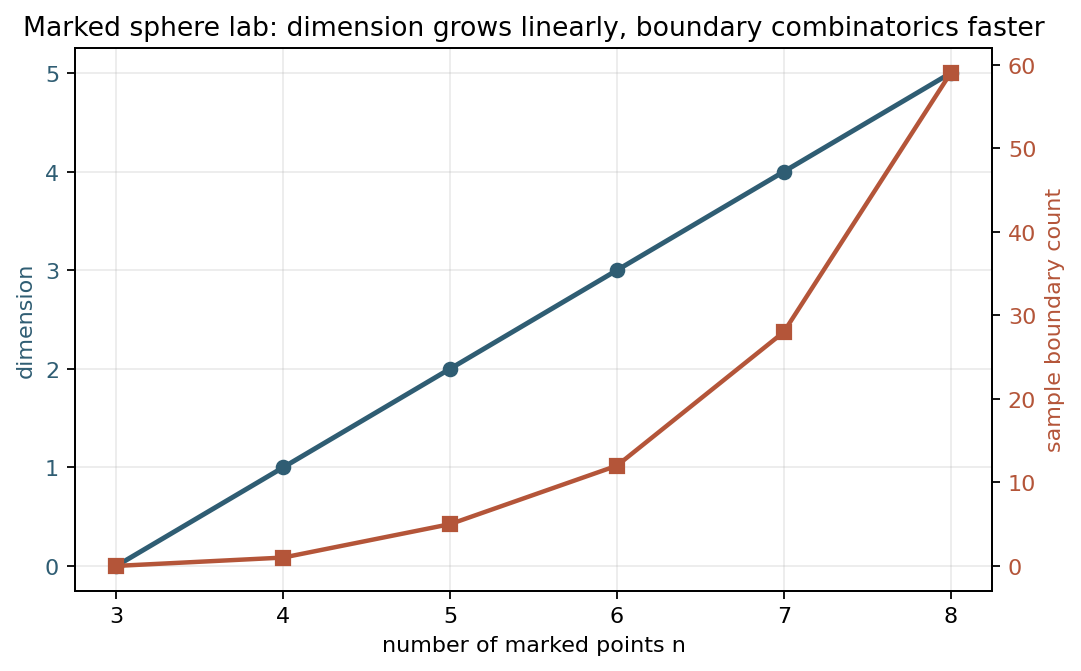

In [7]:
fig, ax1 = plt.subplots(figsize=(7.4, 4.4))
ax1.plot(dim_lab["marked_points_n"], dim_lab["dimension_M0n"], marker="o", lw=2.2, color="#2f5d73", label="dimension n-3")
ax1.set_xlabel("number of marked points n")
ax1.set_ylabel("dimension", color="#2f5d73")
ax1.tick_params(axis="y", labelcolor="#2f5d73")
ax2 = ax1.twinx()
ax2.plot(dim_lab["marked_points_n"], dim_lab["sample_boundary_divisor_count"], marker="s", lw=2.0, color="#b45539", label="boundary split count")
ax2.set_ylabel("sample boundary count", color="#b45539")
ax2.tick_params(axis="y", labelcolor="#b45539")
ax1.set_title("Marked sphere lab: dimension grows linearly, boundary combinatorics faster")
ax1.grid(alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "marked-sphere-dimension-lab.png")
plt.close(fig)
lab_checks = {"dimension_M03": int(dim_lab[dim_lab.marked_points_n == 3].dimension_M0n.iloc[0]), "dimension_M04": int(dim_lab[dim_lab.marked_points_n == 4].dimension_M0n.iloc[0]), "boundary_counts_nonnegative": bool((dim_lab["sample_boundary_divisor_count"] >= 0).all()), "passed": True}
lab_checks["passed"] = lab_checks["dimension_M03"] == 0 and lab_checks["dimension_M04"] == 1 and lab_checks["boundary_counts_nonnegative"]
save_json(lab_checks, UNIT, "checks", "marked-sphere-dimension-lab-checks.json")
display_artifact(fig_path, width=740)


## Takeaways

- Cross-ratios are Mobius-invariant coordinates for four marked points, and their limiting values signal boundary strata.
- Stable genus-zero curves are tree-shaped domains. Stability is the concrete rule that every component must carry at least three special points.
- The Grothendieck-Knudsen compactification adds boundary divisors indexed by stable splittings of the label set.
- Gromov topology tracks components, nodes, marked points, and contractions of tree type, which is exactly what stable-map convergence needs.
- Keel relations and psi-class recursion turn the boundary combinatorics into cohomological computations used by Gromov-Witten axioms.


## Final Sanity Checks

The final cell verifies that Appendix D has the promised source coverage, library routing, visual storyboard, generated figures, ledgers, and JSON checks. It reloads the checks to confirm Mobius invariance of cross-ratio, stability of every component in the sample dual tree, validity of listed boundary splits, topology ledger coverage, psi-dimension compatibility, and `M_0,3`/`M_0,4` dimensions.


In [8]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "cross-ratio-invariance-checks.json",
    CHECK_DIR / "stable-tree-stability-checks.json",
    CHECK_DIR / "gk-boundary-proof-checks.json",
    CHECK_DIR / "gromov-topology-psi-checks.json",
    CHECK_DIR / "marked-sphere-dimension-lab-checks.json",
    FIG_DIR / "cross-ratio-boundary-degeneration.png",
    FIG_DIR / "stable-tree-splitting-map.png",
    FIG_DIR / "gk-boundary-divisor-atlas.png",
    FIG_DIR / "moduli-proof-dependency-map.png",
    FIG_DIR / "marked-sphere-dimension-lab.png",
    TABLE_DIR / "stable-tree-stability-ledger.csv",
    TABLE_DIR / "gk-boundary-splittings.csv",
    TABLE_DIR / "gromov-topology-neighborhood-ledger.csv",
    TABLE_DIR / "psi-class-recursion-ledger.csv",
    TABLE_DIR / "marked-sphere-dimension-lab.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact)
assert_artifact(CHECK_DIR / "source-coverage.json")
assert_artifact(CHECK_DIR / "visual-storyboard.json")
assert_artifact(FIG_DIR / "cross-ratio-boundary-degeneration.png")
assert_artifact(FIG_DIR / "stable-tree-splitting-map.png")

check_names = ["cross-ratio-invariance-checks.json", "stable-tree-stability-checks.json", "gk-boundary-proof-checks.json", "gromov-topology-psi-checks.json", "marked-sphere-dimension-lab-checks.json"]
checks = [json.loads((CHECK_DIR / name).read_text(encoding="utf-8")) for name in check_names]
final_sanity = {
    "artifact_count": len(expected_artifacts),
    "all_json_checks_passed": all(item.get("passed", False) for item in checks),
    "cross_ratio_invariant": checks[0]["invariant"],
    "tree_components_stable": checks[1]["all_components_stable"],
    "boundary_splits_stable": checks[2]["all_listed_splits_stable"],
    "psi_dimension_rule_checked": checks[3]["positive_psi_cases_obey_dimension_rule"],
    "low_mark_dimensions_checked": checks[4]["passed"],
    "passed": True,
}
final_sanity["passed"] = all(value for key, value in final_sanity.items() if key != "artifact_count")
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json")
final_sanity


{'artifact_count': 18,
 'all_json_checks_passed': True,
 'cross_ratio_invariant': True,
 'tree_components_stable': True,
 'boundary_splits_stable': True,
 'psi_dimension_rule_checked': True,
 'low_mark_dimensions_checked': True,
 'passed': True}